## figure for plots
- in this notebook we will read some real data and
- will plot the revenue using figure plus line and scatter plots

In [32]:
import pandas as pd
df=pd.read_csv('ecommerce_dataset.csv',parse_dates=['order_date'])



### Finding monthly Revenue

In [33]:
#and for that i need to find the revenue first

# Revenue = quantity * unit_price * (1 - discount)
df['revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])
# now monthly_revenue
monthly_revenue=(df.set_index('order_date')["revenue"].resample("ME").sum())

print(monthly_revenue)
print(monthly_revenue.index)
print(monthly_revenue.values)

order_date
2022-01-31    40439.5685
2022-02-28    35801.6656
2022-03-31    43536.1132
2022-04-30    31730.2056
2022-05-31    45824.0674
2022-06-30    47012.6980
2022-07-31    13342.1656
Freq: ME, Name: revenue, dtype: float64
DatetimeIndex(['2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30',
               '2022-05-31', '2022-06-30', '2022-07-31'],
              dtype='datetime64[us]', name='order_date', freq='ME')
[40439.5685 35801.6656 43536.1132 31730.2056 45824.0674 47012.698
 13342.1656]


## Line Plot and scatter plot in a single figure

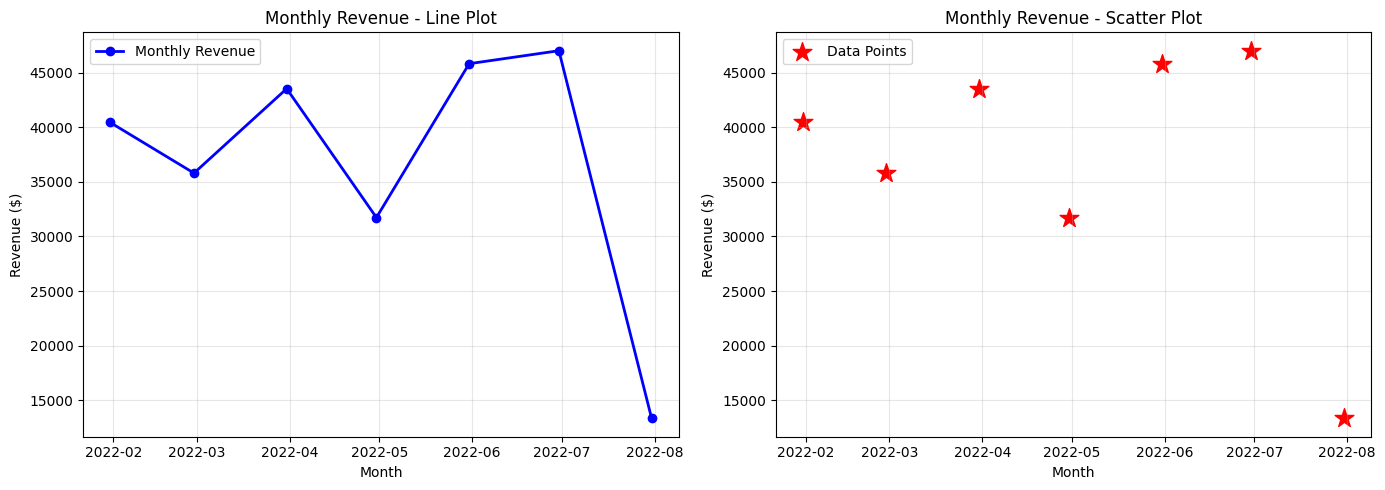

In [34]:
import matplotlib.pyplot as plt

# Create figure with 2 subplots side by side (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Line plot on left
ax1.plot(monthly_revenue.index, monthly_revenue.values, 
         marker='o', linewidth=2, color='blue', label='Monthly Revenue')
ax1.set_title("Monthly Revenue - Line Plot")
ax1.set_xlabel('Month')
ax1.set_ylabel("Revenue ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2 - Scatter plot on right
ax2.scatter(monthly_revenue.index, monthly_revenue.values, 
            marker='*', color='red', s=200, label='Data Points')
ax2.set_title("Monthly Revenue - Scatter Plot")
ax2.set_xlabel('Month')
ax2.set_ylabel("Revenue ($)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()  # Adjust spacing between plots
plt.show()